# 460 — Functional-role matching (concatenated, conjunction)

The **condition-structured** path. Each contact is the three conditions stitched in time,
`[audio | picture | reading]`. We **discretize** to a clustering-exact −1/0/+1 map (the same
segmentation 02 uses — `CLUSTERING_SEG_KWARGS`, no score gate) and assign a
**functional role** only if the contact expresses **every** box of that role's conjunction
template (strict AND) — a box expresses its sign via the clustering **proportion gate** on the
−1/+1 cells. Roles live in `functions/roi_config_concatenated.py` (auditory / visual / motor /
multimodal — **draft, edit them**).

- **Auditory** = HGA in the audio **stimulus** + the **response** of all three (hears stimulus +
  hears own voice ×3). **Motor** = HGA in all three responses. **Visual** = HGA in the picture &
  reading stimuli. The discriminator is the *stimulus* boxes (response is shared motor/feedback —
  only **anatomy** separates those, which is what the POOL map shows).
- One sample per contact; **only contacts with all three conditions** enter.
- `role` = the **most specific** matching template (most boxes); `roles_matched` lists all.

> Discretization needs blob resolution, so `USE_DS=False` (full 129×300) is the faithful baseline;
> `USE_DS=True` downsamples the painted map (faster, coarser).


In [1]:
import os, sys
from pathlib import Path
import numpy as np, pandas as pd
from IPython.display import display, Markdown, Image
sys.path.insert(0, str(Path('..').resolve()))
from functions import lf_pool as P

INPUT_DIR = Path(r'\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\01_FBM_Analysis\outputs\04_ersp_LM_RAWONLY')
if not INPUT_DIR.exists():
    INPUT_DIR = Path('../01_FBM_Analysis/outputs/04_ersp_LM_RAWONLY').resolve()

print('INPUT_DIR :', INPUT_DIR, '| exists:', INPUT_DIR.exists())
print('OUTPUTS   :', P.OUTPUTS_ROOT)
print('COORDS    :', P.COORDS_DIR, '| exists:', P.COORDS_DIR.exists())
print('conditions:', P.CONDITIONS, '| zones:', P.DEFAULT_ZONES)
print('feature sets:', P.FEATURE_SETS, '| window shapes:', P.WINDOW_SHAPES)


INPUT_DIR : \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\01_FBM_Analysis\outputs\04_ersp_LM_RAWONLY | exists: True
OUTPUTS   : \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\pooling
COORDS    : \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\02_FBM_Clustering\outputs\250_recon\fsaverage\coords | exists: True
conditions: ('audio', 'picture', 'reading') | zones: ('perception', 'pre_articulation', 'audio')
feature sets: ('hg', 'bands15') | window shapes: ('boxcar', 'gaussian')


In [2]:
# ---- knobs ----
USE_DS    = True                    # False: full-res discretized baseline (recommended) · True: ds
GRID      = 'ds' if USE_DS else 'full'
print('grid:', GRID, '| roles:', [r['role'] for r in P.ROLE_PARAMS[GRID]['roles']])


grid: ds | roles: ['auditory', 'auditory_v2', 'visual_picture', 'visual_reading', 'picture_stim', 'pic_stim', 'lexical_semantic', 'heteromodal_convergence', 'maintenance', 'premotor planning', 'phonological_encoding', 'motor', 'motor_v2', 'auditory_feedback', 'deactivation', 'NN', 'tag_hga_activation', 'tag_beta_erd', 'tag_low_f_erd', 'tag_theta_tracking', 'ultra_hfa', 'stimulus_active', 'response_active']


## 1 — Load dataset


In [3]:
df_meta, X_full = P.prepare_pooling_dataset(INPUT_DIR)
print('loaded:', len(df_meta), 'rows |', df_meta['condition'].value_counts().to_dict())


[lf_dataset cache hit] \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\_dataset\pooling\_raw_ungated
  8841 samples · X_3d.shape=(8841, 129, 300)
[lf_pool] 8841 samples, 8841 with a contact key, X_3d=(8841, 129, 300)
loaded: 8841 rows | {'picture': 3013, 'audio': 2972, 'reading': 2856}


## 2 — Concatenate raw dB ERSP (one map per all-3-condition contact)


In [4]:
X_input = P.downsample_dataset(X_full) if USE_DS else X_full
df_contacts, X_raw = P.build_concat_raw(df_meta, X_input)
print('contacts:', len(df_contacts), '| X_raw:', X_raw.shape)
df_contacts.head()


[build_X_3d_downsampled] 8841 samples · 15 freq bins · 30 time bins · flat dim = 450
[lf_pool] concat-raw: 2856 contacts, all 3 conditions · X_raw=(2856, 15, 90)
contacts: 2856 | X_raw: (2856, 15, 90)


,patient_id,contact_norm,electrode
0,EL030,AL10,A_L10
1,EL030,AL11,A_L11
2,EL030,AL12,A_L12
3,EL030,AL13,A_L13
4,EL030,AL14,A_L14


## 3 — Raw-dB role matching (mirrors poolv2 Apply button exactly)
Per-role `thr` and `frac` come from `roi_config_concatenated.py`.
`role` = most-specific match; `roles_matched` lists all.


[lf_pool] roles_raw run -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\pooling\roles_raw\ds\runs\20260630_161106
[lf_pool] role table (raw dB): (2856, 7)


,role,n_matched,n_primary
0,tag_low_f_erd,620,290
1,tag_beta_erd,413,350
2,tag_theta_tracking,275,188
3,tag_hga_activation,158,122
4,auditory,153,67
5,ultra_hfa,131,74
6,response_active,122,0
7,premotor planning,61,59
8,stimulus_active,58,0
9,NN,32,24


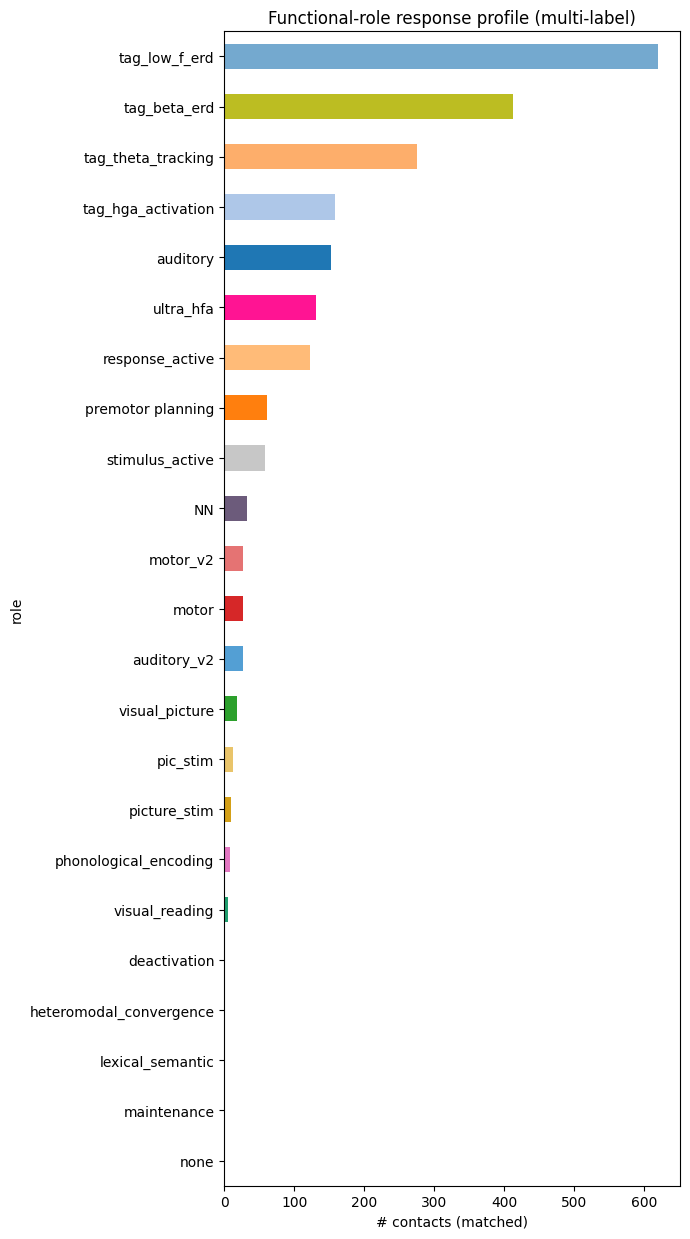

In [5]:
import matplotlib.pyplot as plt
df_role = P.build_role_table_raw(df_contacts, X_raw, grid=GRID)
counts = P.role_counts(df_role)
display(counts)
# role_counts is multi-label: n_matched = contacts where the role is in roles_matched
# (a contact counts toward every role it shows); n_primary = most-specific winner.
ax = counts.set_index('role')['n_matched'].plot.barh(figsize=(7, 0.5 * len(counts) + 1),
        color=[P.role_colors(GRID).get(r, '#888') for r in counts['role']])
ax.set_xlabel('# contacts (matched)'); ax.set_title('Functional-role response profile (multi-label)')
ax.invert_yaxis(); plt.tight_layout(); plt.show()


## 3b — Role co-occurrence (multi-label overlap)
How often each pair of roles is matched by the **same** contact (via `roles_matched`).
The **diagonal** = total contacts matching that role; **off-diagonal** = the size of each
pairwise intersection — the "Venn" view across all roles at once (e.g. how many contacts
are *both* `auditory` and `auditory_suppression`).


In [6]:
df_role

,patient_id,contact_norm,electrode,grid,role,roles_matched,n_roles
0,EL030,AL10,A_L10,ds,none,,0
1,EL030,AL11,A_L11,ds,none,,0
2,EL030,AL12,A_L12,ds,tag_hga_activation,tag_hga_activation;response_active,2
3,EL030,AL13,A_L13,ds,motor,motor;tag_hga_activation;ultra_hfa;response_ac...,4
4,EL030,AL14,A_L14,ds,motor,motor;tag_hga_activation;ultra_hfa;response_ac...,4
...,...,...,...,...,...,...,...
2851,PAT_6854,X2M4,X2m4,ds,tag_low_f_erd,tag_low_f_erd,1
2852,PAT_6854,X2M5,X2m5,ds,tag_low_f_erd,tag_low_f_erd,1
2853,PAT_6854,X2M6,X2m6,ds,tag_low_f_erd,tag_low_f_erd,1
2854,PAT_6854,X2M7,X2m7,ds,tag_low_f_erd,tag_low_f_erd,1


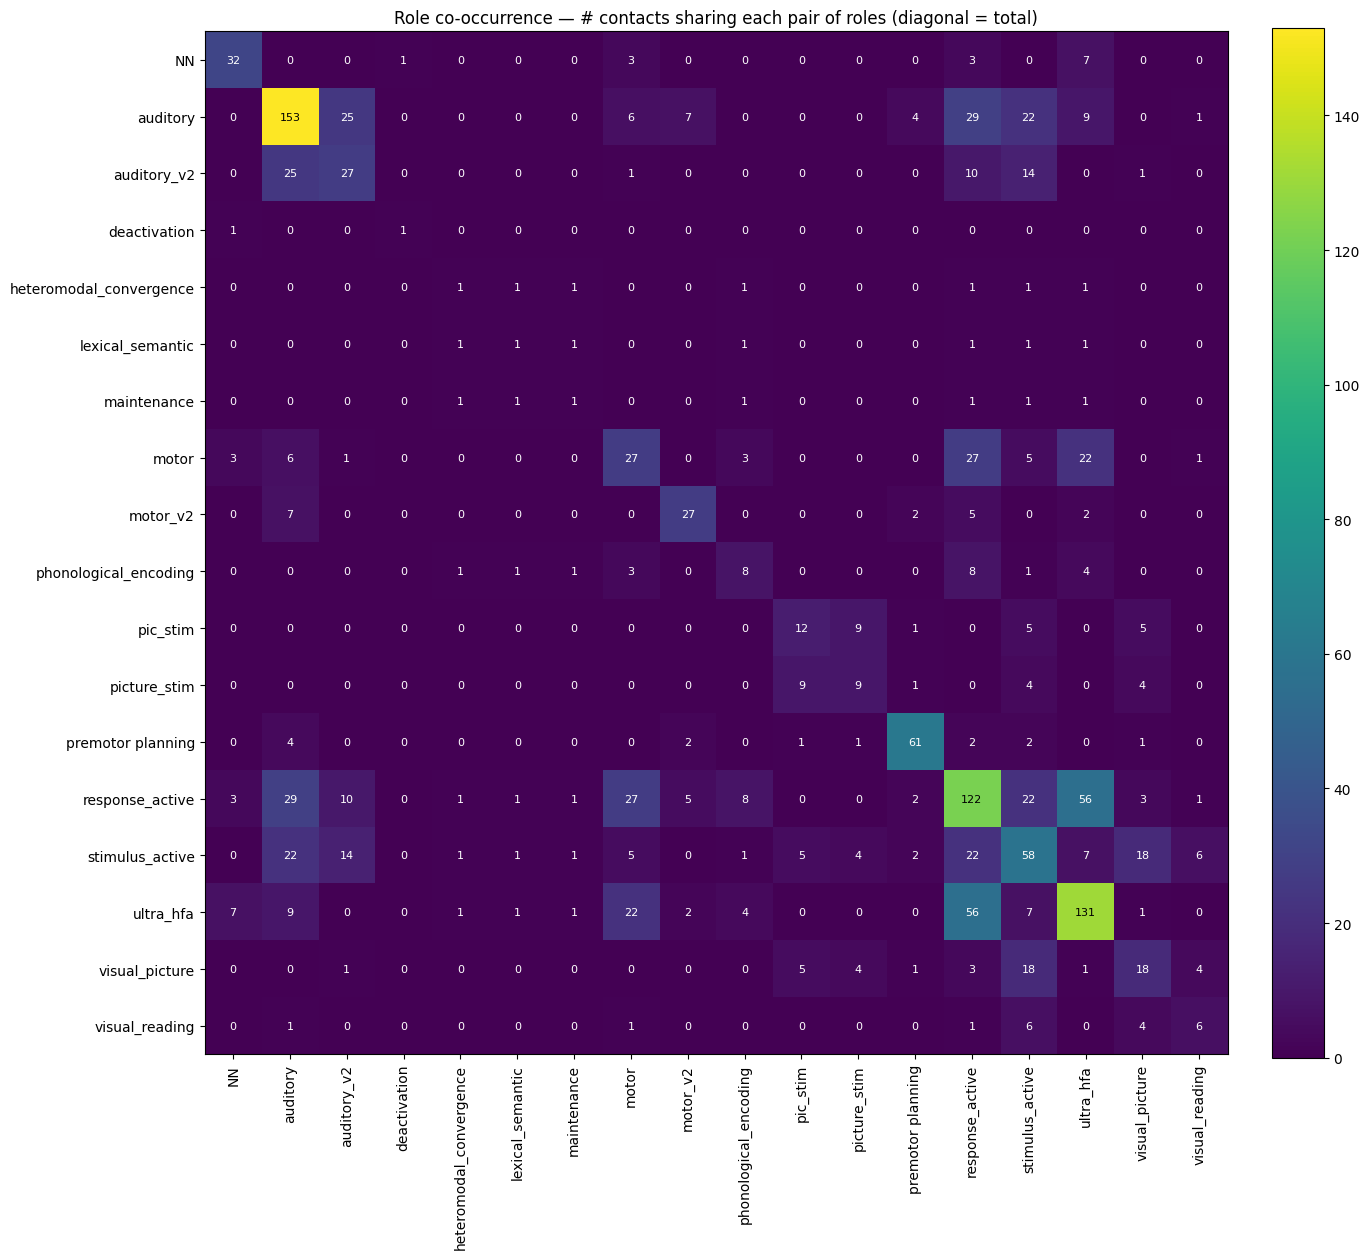

In [7]:
import numpy as np, matplotlib.pyplot as plt
M = P.role_membership(df_role)                       # one row/contact, bool col per matched role
role_cols = [c for c in M.columns if c not in ('patient_id', 'contact_norm')
             and not c.startswith('tag_')]
B = M[role_cols].to_numpy().astype(int)
C = B.T @ B                                          # co-occurrence counts; diagonal = n_matched
fig, ax = plt.subplots(figsize=(0.6 * len(role_cols) + 3, 0.6 * len(role_cols) + 3))
im = ax.imshow(C, cmap='viridis')
ax.set_xticks(range(len(role_cols))); ax.set_xticklabels(role_cols, rotation=90)
ax.set_yticks(range(len(role_cols))); ax.set_yticklabels(role_cols)
vmax = int(C.max()) if C.size else 1
for i in range(len(role_cols)):
    for j in range(len(role_cols)):
        ax.text(j, i, int(C[i, j]), ha='center', va='center', fontsize=8,
                color='white' if C[i, j] < vmax * 0.6 else 'black')
ax.set_title('Role co-occurrence — # contacts sharing each pair of roles (diagonal = total)')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

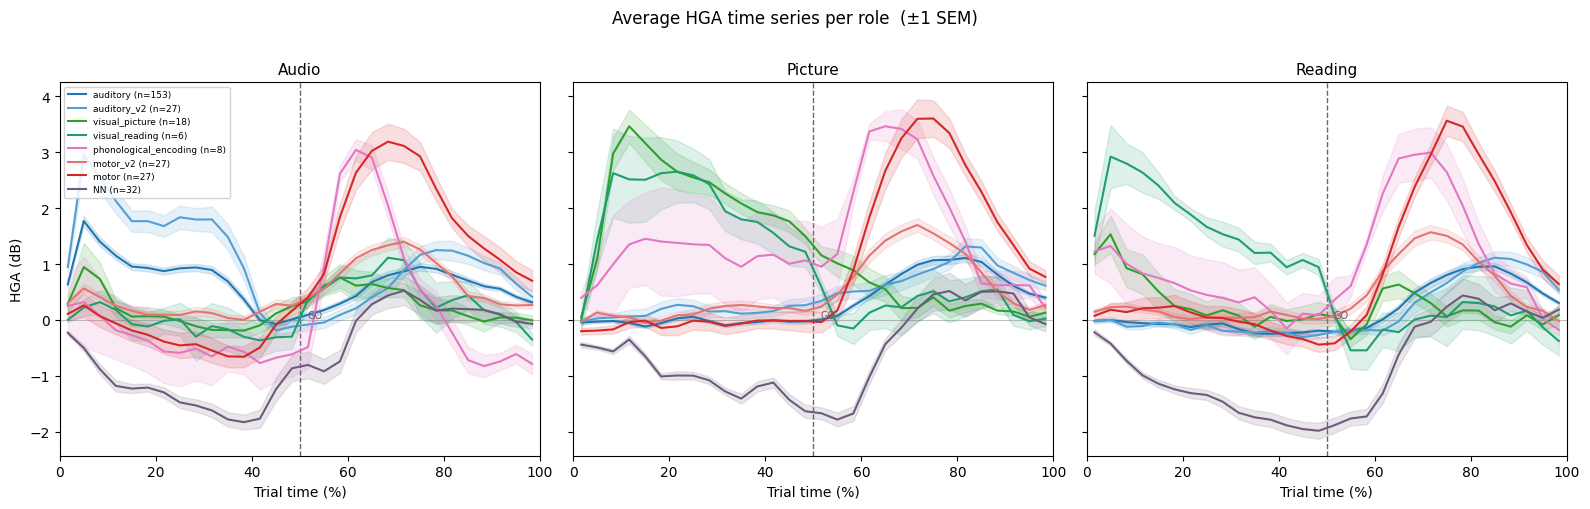

Updated: role_info.json
Updated: role_info.json

Onset order per condition:

  AUDIO:
    auditory                             1.7%
    auditory_v2                          1.7%
    visual_picture                       5.0%
    motor_v2                             5.0%
    NN                                   5.0%
    phonological_encoding                21.7%
    motor                                31.7%
    visual_reading                       55.0%
    auditory_feedback                    100.0%

  PICTURE:
    visual_picture                       5.0%
    visual_reading                       5.0%
    phonological_encoding                5.0%
    NN                                   8.3%
    auditory_v2                          58.3%
    motor_v2                             58.3%
    motor                                58.3%
    auditory                             65.0%
    auditory_feedback                    100.0%

  READING:
    visual_picture                       1.7%
    v

In [8]:
import json, importlib
importlib.reload(P)   # reload lf_pool in case you edited it

POOL_OUT       = P.OUTPUTS_ROOT / 'pool_web'
POOL_OUT_GAUSS = P.OUTPUTS_ROOT / 'pool_web_gaussian'

# Layer-1 functional roles to plot — edit this list to add/remove roles
PLOT_ROLES = [
    "auditory", "auditory_v2",
    "visual_picture", "visual_reading", # "pic_stim",
    # "lexical_semantic", "heteromodal_convergence", "maintenance",
    "premotor planning", "phonological_encoding",
    "motor_v2", "auditory_feedback",
    "motor", "NN",
]

# role_info.json supplies colors + metadata for the legend
with open(POOL_OUT / "role_info.json", encoding="utf-8") as f:
    role_info = json.load(f)

# Plot HGA time series (multi-label: contacts appear in every role they match)
fig, onset_dict = P.plot_role_hga_timeseries(
    df_contacts, X_raw, df_role,
    role_info, roles=PLOT_ROLES, grid=GRID, onset_thr_db=0.5,
    out_png=POOL_OUT / "hga_timeseries.png")
plt.show()

# Patch onset_t_pct (earliest across conditions) into both role_info.json files
for path in [POOL_OUT / "role_info.json", POOL_OUT_GAUSS / "role_info.json"]:
    with open(path, encoding="utf-8") as f:
        ri = json.load(f)
    for rname, cond_onsets in onset_dict.items():
        if rname in ri:
            ri[rname]["onset_t_pct"] = round(min(cond_onsets.values()), 1)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(ri, f, indent=1)
    print(f"Updated: {path.name}")

print("\nOnset order per condition:")
for cond in ["audio", "picture", "reading"]:
    print(f"\n  {cond.upper()}:")
    ranked = sorted(onset_dict.items(), key=lambda x: x[1][cond])
    for role, onsets in ranked:
        print(f"    {role:35s}  {onsets[cond]:.1f}%")

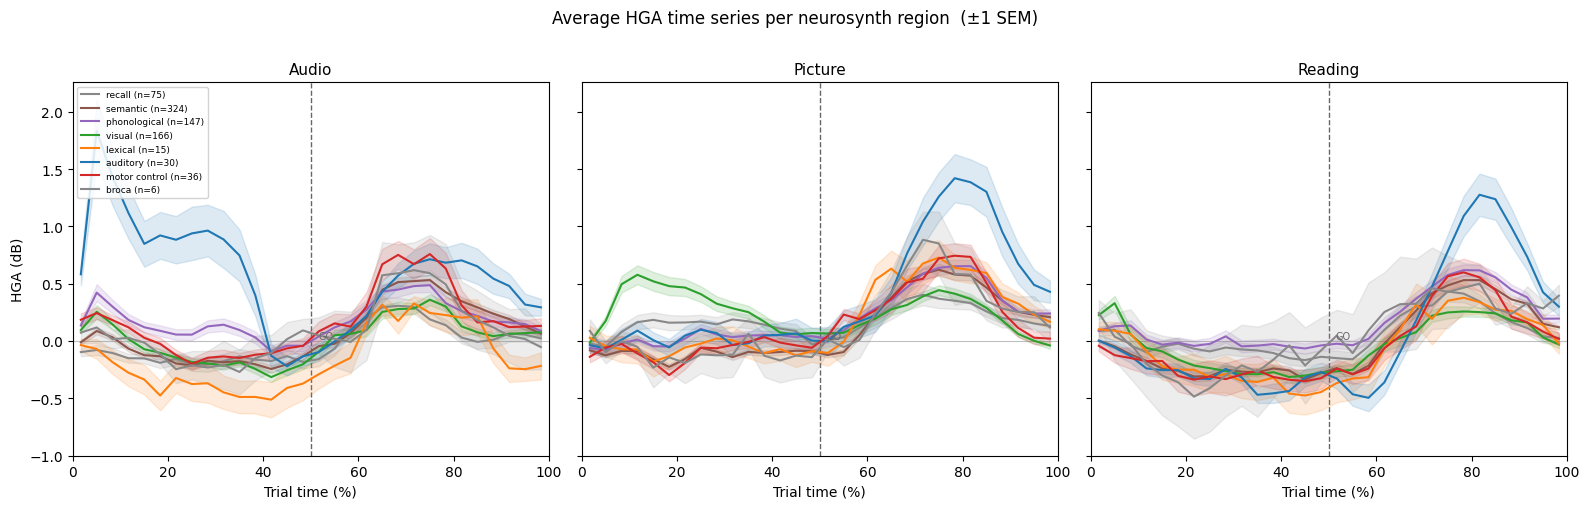

Region onset order:


TypeError: '<' not supported between instances of 'dict' and 'dict'

In [10]:
import json
importlib.reload(P)

NS_OUT = P.OUTPUTS_ROOT / 'neurosynth'

ns_labels = pd.read_csv(NS_OUT / 'neurosynth_labels.csv')
with open(NS_OUT / 'neurosynth_info.json', encoding='utf-8') as f:
    region_info = json.load(f)

fig, ns_onset_dict = P.plot_region_hga_timeseries(
    df_contacts, X_raw, ns_labels,
    region_info, grid=GRID, onset_thr_db=0.5,
    out_png=NS_OUT / 'hga_timeseries.png')
plt.show()

print("Region onset order:")
for k, v in sorted(ns_onset_dict.items(), key=lambda x: x[1]):
    print(f"  {k:35s}  {v:.1f}%")


## 4 — Export for the POOL web page
Writes `contacts_pool.csv` (xyz + role + colour) + `pool_index.json` to the **stable**
`outputs/pooling/pool_web/` path that `web/pool.html` (Niivue, in your `lorafanda.github.io`
repo) reads via raw-GitHub. Reuses the MOBA fsaverage meshes. **Commit + push** that folder so
the page can fetch it.


In [ ]:
coords = P.load_coords()
# df_meta carries each contact's ERSP file_path per condition -> pool_samples.json
# so pool.html can show the selected pool's ERSPs (samples strip).
web = P.export_pool_web(df_role, coords, P.OUTPUTS_ROOT / 'pool_web', grid=GRID, df_meta=df_meta)
print('POOL web data ->', web)
# per-role info cards (description + box/gaussian template on a representative ERSP) for the web info panel
P.export_role_info(INPUT_DIR, df_role, P.OUTPUTS_ROOT / 'pool_web', grid=GRID)
# downsampled raw-ERSP cube for the poolv2 interactive role designer (fraction-above-threshold, client-side)
P.export_pool_cube(INPUT_DIR, df_contacts, P.OUTPUTS_ROOT / 'pool_cube')
